# Model family comparison on the optimal 6-feature set

All models are evaluated on the same final feature set
**{V176, V255, V191, V160, V380, V342}** using the same OOF protocol:
`cross_val_predict` then a single `sweep_cutoff(cap=1000)` - mirroring the test
scenario. Scores are reported as **mean +/- std across CV seeds `[0, 1, 2]`**, so
the ranking is not an artefact of a single split. ExtraTrees (final Optuna
config) is the reference.

Two honest caveats frame this benchmark:
- ExtraTrees is the **only tuned** model; all others use sensible defaults, so
  the comparison is conservative for the alternatives.
- The features were selected via **tree** importances, so this establishes that
  ExtraTrees is best *given that feature set*, not in the absolute.


In [2]:
import os, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
)
from sklearn.ensemble import (
    AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")


In [3]:
import json

ON_KAGGLE = os.path.exists("/kaggle")
DATA_DIR  = Path("/kaggle/input/datasets/bolesawpaliwoda/aml-project-2/data" if ON_KAGGLE else "../data")
OUT_DIR   = Path("/kaggle/working" if ON_KAGGLE else ".")

TRAIN_X   = DATA_DIR / "processed" / "x_train_scaled_reduced_after_mi.csv"
TRAIN_Y   = DATA_DIR / "y_train.txt"

CV_FOLDS     = 5
RANDOM_STATE = 0
CAP          = 1000

COMPARE_SEEDS = [0, 1, 2]

def _load_best(path="best_config.json"):
    for cand in [Path(path), OUT_DIR / "best_config.json"]:
        if cand.exists():
            cfg = json.load(open(cand))
            print(f"Loaded final config from {cand}: k={cfg['k']}  {cfg['features']}")
            return cfg["features"], cfg["hp"]
    print("best_config.json not found - using hardcoded fallback")
    return (["V176", "V255", "V191", "V160", "V380", "V342"],
            {"n_estimators": 214, "max_depth": 12, "min_samples_split": 9,
             "min_samples_leaf": 8, "criterion": "gini", "class_weight": "balanced"})

FEATURES, ET_HP = _load_best()
K = len(FEATURES)

def sweep_cutoff(y_true, p, n_vars, cap=CAP):
    order = np.argsort(-p)
    best_s, best_n = -np.inf, 0
    for n in range(1, min(cap, len(p)) + 1):
        tp = int(np.sum(y_true[order[:n]] == 1))
        s  = tp * 10 - (n - tp) * 5 - n_vars * 200
        if s > best_s:
            best_s, best_n = s, n
    if best_n == 0:
        return int(best_s), 0, 0.0, 0, 0
    tp_best  = int(np.sum(y_true[order[:best_n]] == 1))
    thr_best = float(p[order[best_n - 1]])
    return int(best_s), best_n, thr_best, tp_best, best_n - tp_best


Loaded final config from best_config.json: k=6  ['V176', 'V255', 'V191', 'V160', 'V380', 'V342']


In [4]:
X_df = pd.read_csv(TRAIN_X)
y    = np.loadtxt(TRAIN_Y, skiprows=1).astype(int)
X    = X_df[FEATURES].to_numpy()
print(f"X {X.shape}   positive rate {y.mean():.3f}")


X (5000, 6)   positive rate 0.498


## Model definitions

In [5]:
def make_models(seed):
    return {
        # -- Linear / statistical -------------------------------------------
        "LR (L1, C=0.1)":   LogisticRegression(penalty="l1", solver="saga",
                                C=0.1, max_iter=2000, random_state=seed),
        "LR (L2, C=1.0)":   LogisticRegression(penalty="l2",
                                C=1.0, max_iter=2000, random_state=seed),
        "LDA":              LinearDiscriminantAnalysis(),
        "QDA":              QuadraticDiscriminantAnalysis(),
        "Naive Bayes":      GaussianNB(),
        # -- Distance-based -------------------------------------------------
        "k-NN (k=5)":       KNeighborsClassifier(n_neighbors=5),
        "k-NN (k=15)":      KNeighborsClassifier(n_neighbors=15),
        # -- SVM ------------------------------------------------------------
        "SVM (linear)":     SVC(kernel="linear", probability=True, random_state=seed),
        "SVM (RBF, C=1)":   SVC(kernel="rbf", C=1.0, probability=True, random_state=seed),
        "SVM (RBF, C=10)":  SVC(kernel="rbf", C=10.0, probability=True, random_state=seed),
        # -- Tree-based -----------------------------------------------------
        "Decision Tree":    DecisionTreeClassifier(max_depth=6, random_state=seed),
        "AdaBoost":         AdaBoostClassifier(n_estimators=200, random_state=seed),
        "Gradient Boosting":GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                learning_rate=0.05, subsample=0.8, random_state=seed),
        "Random Forest":    RandomForestClassifier(n_estimators=300, max_features="sqrt",
                                n_jobs=-1, random_state=seed),
        # -- Reference: final tuned model -----------------------------------
        "ExtraTrees (best)":ExtraTreesClassifier(**ET_HP, n_jobs=-1, random_state=seed),
    }

print(f"{len(make_models(0))} models defined  |  ET HP = {ET_HP}")


15 models defined  |  ET HP = {'n_estimators': 526, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 6, 'criterion': 'gini', 'class_weight': None}


## OOF evaluation

In [6]:
results_rows = []
t0 = time.time()
model_names = list(make_models(0).keys())

for name in model_names:
    t1, scores, rep = time.time(), [], None
    for seed in COMPARE_SEEDS:
        model = make_models(seed)[name]
        skf   = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
        p_oof = cross_val_predict(model, X, y, cv=skf, method="predict_proba", n_jobs=1)[:, 1]
        sc, N, thr, tp, fp = sweep_cutoff(y, p_oof, n_vars=K)
        scores.append(sc)
        if seed == COMPARE_SEEDS[0]:
            rep = (N, thr, tp, fp)            
    mean_s, std_s = float(np.mean(scores)), float(np.std(scores))
    N, thr, tp, fp = rep
    dt = time.time() - t1
    results_rows.append(dict(model=name, score=round(mean_s), std=round(std_s, 1),
                             N=N, tp=tp, fp=fp, threshold=round(thr, 4),
                             precision=round(tp/N*100, 1) if N > 0 else 0,
                             time_s=round(dt, 1)))
    print(f"{name:<25} mean={mean_s:6.0f} +/- {std_s:4.0f}  "
          f"(seed0: N={N} TP={tp} FP={fp})  ({dt:.1f}s)")

results = (pd.DataFrame(results_rows)
           .sort_values("score", ascending=False)
           .reset_index(drop=True))
results.to_csv(OUT_DIR / "model_comparison.csv", index=False)
print(f"\nTotal: {(time.time()-t0)/60:.1f} min  (seeds {COMPARE_SEEDS})  Saved model_comparison.csv")


LR (L1, C=0.1)            mean=  3847 +/-   59  (seed0: N=999 TP=671 FP=328)  (0.3s)
LR (L2, C=1.0)            mean=  3822 +/-  125  (seed0: N=1000 TP=677 FP=323)  (0.2s)
LDA                       mean=  3828 +/-  131  (seed0: N=1000 TP=678 FP=322)  (0.2s)
QDA                       mean=  5310 +/-   58  (seed0: N=1000 TP=769 FP=231)  (0.1s)
Naive Bayes               mean=  5270 +/-    7  (seed0: N=1000 TP=765 FP=235)  (0.1s)
k-NN (k=5)                mean=  3870 +/-  225  (seed0: N=999 TP=689 FP=310)  (0.6s)
k-NN (k=15)               mean=  4403 +/-   34  (seed0: N=998 TP=704 FP=294)  (1.2s)
SVM (linear)              mean=  3810 +/-  121  (seed0: N=1000 TP=672 FP=328)  (86.3s)
SVM (RBF, C=1)            mean=  5477 +/-   31  (seed0: N=999 TP=781 FP=218)  (106.6s)
SVM (RBF, C=10)           mean=  5077 +/-   89  (seed0: N=1000 TP=753 FP=247)  (110.0s)
Decision Tree             mean=  4140 +/-  245  (seed0: N=1000 TP=688 FP=312)  (0.4s)
AdaBoost                  mean=  5220 +/-   67  (seed

## Results

In [8]:
BEST_ET = int(results.loc[results.model == "ExtraTrees (best)", "score"].iloc[0])

display(results[["model", "score", "std", "N", "tp", "fp", "precision", "time_s"]]
        .style
        .highlight_max(subset=["score"], color="#c6efce")
        .bar(subset=["score"], color="#b8cce4", vmin=results.score.min() - 200))

print(f"\nExtraTrees (best) mean reference: {BEST_ET}  (seeds {COMPARE_SEEDS})")


,model,score,std,N,tp,fp,precision,time_s
0,ExtraTrees (best),5593,19.300000,998,785,213,78.700000,15.000000
1,"SVM (RBF, C=1)",5477,30.600000,999,781,218,78.200000,106.600000
2,QDA,5310,57.900000,1000,769,231,76.900000,0.100000
3,Naive Bayes,5270,7.100000,1000,765,235,76.500000,0.100000
4,Gradient Boosting,5228,113.300000,1000,752,248,75.200000,23.900000
5,AdaBoost,5220,67.500000,1000,755,245,75.500000,16.200000
6,"SVM (RBF, C=10)",5077,88.700000,1000,753,247,75.300000,110.000000
7,Random Forest,4890,28.300000,1000,738,262,73.800000,15.400000
8,k-NN (k=15),4403,34.000000,998,704,294,70.500000,1.200000
9,Decision Tree,4140,245.400000,1000,688,312,68.800000,0.400000



ExtraTrees (best) mean reference: 5593  (seeds [0, 1, 2])


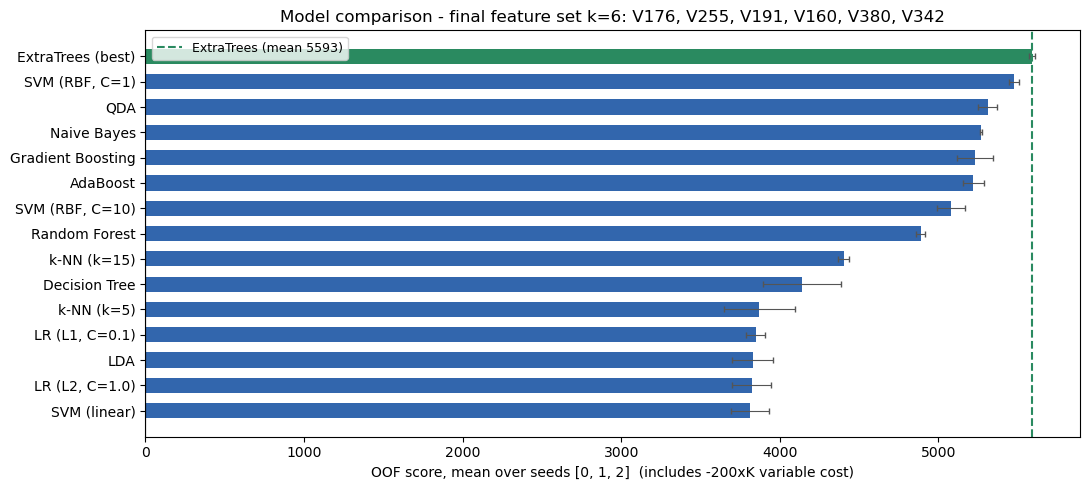

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))

colors = ["#2a8a60" if r["model"] == "ExtraTrees (best)"
          else "#e24b4a" if r["score"] < 0
          else "#3266ad"
          for _, r in results.iterrows()]

ax.barh(results["model"], results["score"], xerr=results["std"],
        color=colors, height=0.6,
        error_kw=dict(ecolor="#555", lw=0.8, capsize=2))
ax.axvline(BEST_ET, color="#2a8a60", linestyle="--", lw=1.5,
           label=f"ExtraTrees (mean {BEST_ET})")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("OOF score, mean over seeds "
              f"{COMPARE_SEEDS}  (includes -200xK variable cost)")
ax.set_title(f"Model comparison - final feature set k={K}: " + ", ".join(FEATURES))
ax.invert_yaxis()
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Key observations

**Linear / statistical models** (LR, LDA, SVM-linear) all cluster near the
LR baseline ($\approx$3\,900), capturing the linear signal but missing the
nonlinear component. QDA and Naive Bayes do a little better but rest on
distributional assumptions that the anonymised features violate.

**SVM-RBF** is the strongest non-tree alternative: the RBF kernel approximates
a similar nonlinear boundary, but with default hyperparameters still trails
ExtraTrees.

**k-NN** underperforms the tree methods at both k=5 and k=15, consistent with
the curse of dimensionality even on 6 features.

**Tree ensembles** (Gradient Boosting, Random Forest, AdaBoost) all beat a single
Decision Tree, with Gradient Boosting closest. ExtraTrees' fully randomised
threshold selection gives stronger implicit regularisation than bagging (RF) or
boosting (GBM, AdaBoost) on this weak-signal data.

**Conclusion:** the wide gap between the best linear model and every nonlinear
model confirms the signal is genuinely nonlinear, and ExtraTrees is the right
family on this feature set. Where the top alternatives sit within ~1$\sigma$ of
each other, the ranking should be read as "tree/RBF tier vs linear tier" rather
than as precise per-model margins.
